# Mutual Fund Performance Analytics

This notebook performs quantitative performance analysis of mutual fund schemes using historical NAV data. Metrics such as CAGR, Sharpe Ratio, Sortino Ratio, Alpha, Beta, Maximum Drawdown, and Fund Scorecards are computed to evaluate and compare fund performance.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from scipy.stats import linregress

plt.style.use("ggplot")
sns.set_style("whitegrid")

In [11]:
nav = pd.read_csv("../data/processed/clean_nav_history.csv")
performance = pd.read_csv("../data/processed/clean_scheme_performance.csv")
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")
fund_master = pd.read_csv("../data/processed/clean_fund_master.csv")

In [12]:
nav["date"] = pd.to_datetime(nav["date"])
benchmark["date"] = pd.to_datetime(benchmark["date"])

In [13]:
pivot_nav = nav.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)
pivot_nav.head()


amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632,...,120843,120844,125497,125498,148567,148568,148569,149322,149323,149324
date,,,,,,,,,,,,,,,,,,,,,
2022-01-03,520.4608,26.3169,107.3758,305.0996,38.5736,310.7415,89.8728,119.2905,191.0721,42.8339,...,49.9131,3180.6318,560.1443,117.5969,70.2514,84.0757,28.8620,348.7159,78.4622,81.6814
2022-01-04,515.0971,26.2234,105.9447,305.4514,38.1545,310.6977,90.8724,120.6402,189.0737,42.8033,...,50.8195,3181.4042,560.7052,117.0077,71.6085,85.4096,29.1038,345.7198,78.5000,80.8239
2022-01-05,521.7239,26.2221,105.4800,306.6324,38.1775,310.8165,90.1565,121.4580,188.0701,43.0564,...,50.1942,3182.8754,563.0884,116.4011,71.3264,84.7554,29.5489,343.4795,79.1806,80.6143
2022-01-06,515.7880,26.1728,104.9350,305.9800,37.0665,310.7719,91.5338,125.2386,190.4545,43.2088,...,50.6213,3184.9450,561.0675,116.0861,72.1746,84.3563,29.5744,342.1680,78.0831,79.9386
2022-01-07,515.1639,26.2261,104.3318,304.0480,37.9845,310.8388,90.6762,124.1321,187.3124,42.9585,...,49.9391,3185.5042,559.5420,114.6164,72.2118,84.9469,29.6091,340.7757,78.4202,80.8723


In [14]:
daily_returns = pivot_nav.pct_change()
daily_returns.head()

amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632,...,120843,120844,125497,125498,148567,148568,148569,149322,149323,149324
date,,,,,,,,,,,,,,,,,,,,,
2022-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-04,-0.010306,-0.003553,-0.013328,0.001153,-0.010865,-0.000141,0.011122,0.011314,-0.010459,-0.000714,...,0.018160,0.000243,0.001001,-0.005010,0.019318,0.015865,0.008378,-0.008592,0.000482,-0.010498
2022-01-05,0.012865,-0.000050,-0.004386,0.003866,0.000603,0.000382,-0.007878,0.006779,-0.005308,0.005913,...,-0.012304,0.000462,0.004250,-0.005184,-0.003939,-0.007660,0.015294,-0.006480,0.008670,-0.002593
2022-01-06,-0.011377,-0.001880,-0.005167,-0.002128,-0.029101,-0.000143,0.015277,0.031127,0.012678,0.003540,...,0.008509,0.000650,-0.003589,-0.002706,0.011892,-0.004709,0.000863,-0.003818,-0.013861,-0.008382
2022-01-07,-0.001210,0.002036,-0.005748,-0.006314,0.024766,0.000215,-0.009369,-0.008835,-0.016498,-0.005793,...,-0.013477,0.000176,-0.002719,-0.012660,0.000515,0.007001,0.001173,-0.004069,0.004317,0.011680


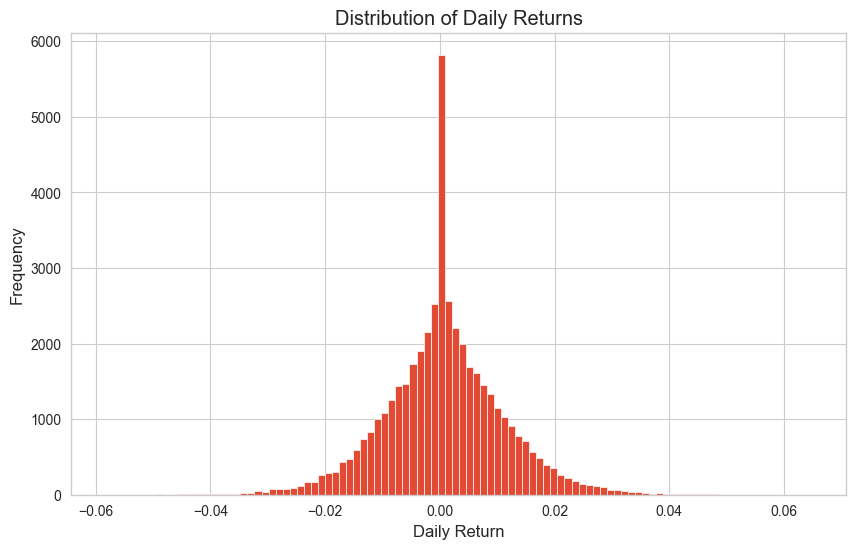

In [16]:
plt.figure(figsize=(10,6))

daily_returns.stack().hist(
    bins=100
)

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.savefig(
    "../reports/daily_return_distribution.png",
    bbox_inches="tight"
)

plt.show()

### Insight

The distribution of daily returns is approximately centered around zero, indicating that most daily price movements are small, with occasional extreme gains or losses.

## Compound Annual Growth Rate (CAGR) Analysis

CAGR measures the annualized growth rate of an investment over a specific time period assuming profits are reinvested. It provides a standardized measure to compare the long-term performance of different mutual funds.

In [ ]:
cagr_results = []

for fund in pivot_nav.columns:

    fund_nav = pivot_nav[fund].dropna()

    if len(fund_nav) < 252:
        continue

    # Latest NAV

    end_nav = fund_nav.iloc[-1]

    # 1 Year CAGR

    if len(fund_nav) >= 252:
        start_1yr = fund_nav.iloc[-252]
        cagr_1yr = (end_nav / start_1yr) ** (1/1) - 1
    else:
        cagr_1yr = np.nan

    # 3 Year CAGR

    if len(fund_nav) >= 756:
        start_3yr = fund_nav.iloc[-756]
        cagr_3yr = (end_nav / start_3yr) ** (1/3) - 1
    else:
        cagr_3yr = np.nan

    # 5 Year CAGR

    if len(fund_nav) >= 1260:
        start_5yr = fund_nav.iloc[-1260]
        cagr_5yr = (end_nav / start_5yr) ** (1/5) - 1
    else:
        cagr_5yr = np.nan

    cagr_results.append([
        fund,
        cagr_1yr * 100,
        cagr_3yr * 100,
        cagr_5yr * 100
    ])

# Creating DataFrame

cagr_df = pd.DataFrame(cagr_results,columns=["amfi_code","CAGR_1Y","CAGR_3Y","CAGR_5Y"])

cagr_df.head()

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y
0,100016,-3.305509,-0.031628,NaN
1,100025,2.501760,4.614329,NaN
2,100033,47.734590,33.629211,NaN
3,101206,45.093927,32.528591,NaN
4,101207,-24.242050,-2.696475,NaN


In [ ]:
top_funds = cagr_df.sort_values(by="CAGR_3Y",ascending=False
)

top_funds.head(10)

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y
16,119094,30.918202,36.066017,NaN
2,100033,47.734590,33.629211,NaN
3,101206,45.093927,32.528591,NaN
34,148567,14.580715,31.278573,NaN
25,120505,30.353412,30.206535,NaN
24,120504,11.500730,28.369809,NaN
21,119598,84.532246,27.814418,NaN
19,119551,48.883881,27.727428,NaN
8,102887,12.727860,25.663042,NaN
30,120843,28.481073,25.661883,NaN


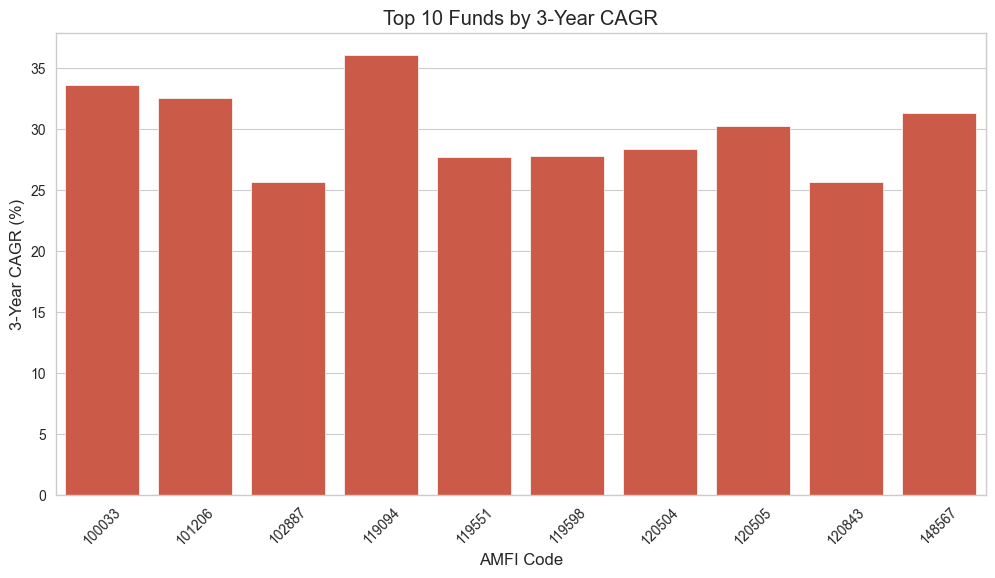

In [19]:
plt.figure(figsize=(12,6))

top10 = cagr_df.sort_values(
    by="CAGR_3Y",
    ascending=False
).head(10)

sns.barplot(
    data=top10,
    x="amfi_code",
    y="CAGR_3Y"
)

plt.title("Top 10 Funds by 3-Year CAGR")
plt.xlabel("AMFI Code")
plt.ylabel("3-Year CAGR (%)")

plt.xticks(rotation=45)

plt.savefig(
    "../reports/top10_cagr.png",
    bbox_inches="tight"
)

plt.show()

### Insight

Several funds generated strong long-term returns, with top-performing schemes significantly outperforming their peers on a 3-year CAGR basis.

In [ ]:
cagr_df.to_csv("../reports/cagr_table.csv",index=False)

print("CAGR table saved successfully.")